# Servoloop Notebook

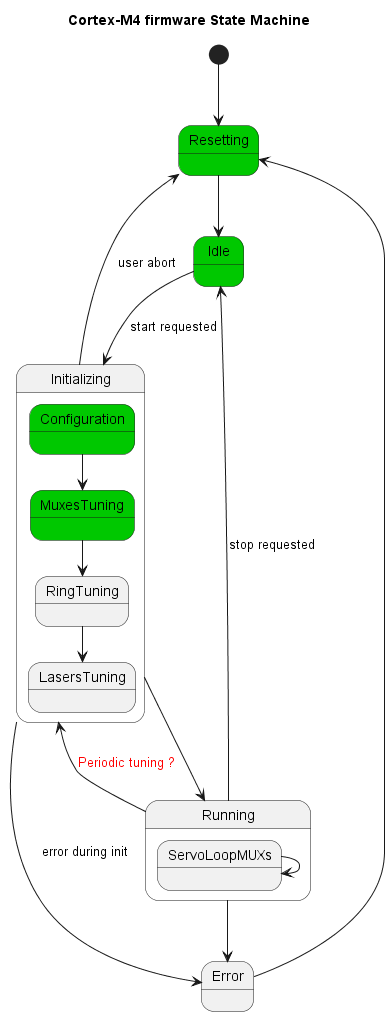
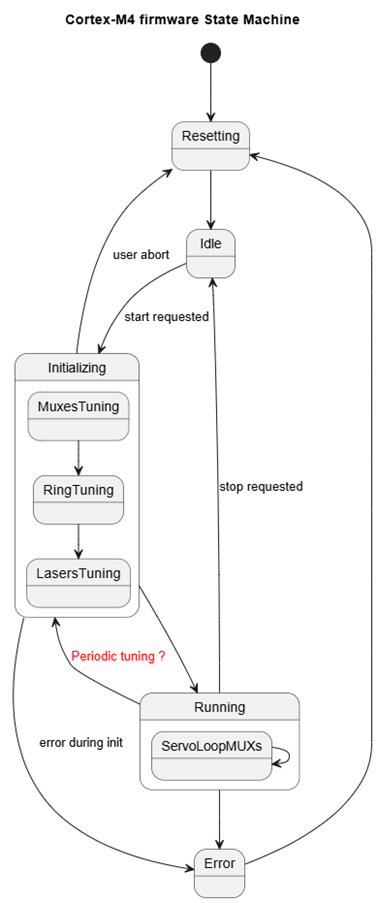

### Load servoloop functions

In [1]:

from servoloop_v0 import *
%matplotlib inline

### Connect to server

In [2]:
server = getDefaultServer()
port = getDefaultPort()

api = connect_to_server(server, port)
# Serial Number
ret = api.scintil_hal_config_get_serial_number()
assert ret["errcode"] == scintil_hal_error_bit_t.SCINTIL_HAL_ERROR_NONE
logging.info("Board S/N: {}".format(ret["serial_number"]))
# Version
ret = api.scintil_hal_sys_get_sw_version()
assert ret["errcode"] == scintil_hal_error_bit_t.SCINTIL_HAL_ERROR_NONE
logging.info("Version: {}.{}.{}".format(ret["version"].major, ret["version"].minor, ret["version"].patch))
# TEC S/N
ret = api.scintil_hal_tec_get_serial_number()
assert ret["errcode"] == scintil_hal_error_bit_t.SCINTIL_HAL_ERROR_NONE
logging.info("TEC S/N: {}".format(ret["sn"]))

INFO:root:Connecting to Scintil HTTP Server 127.0.0.1:80
INFO:root:Remote api version : 0.9.18-7-g80c4b5fe7 local version : 0.9.18-7-g80c4b5fe7
INFO:root:Remote cut : 1 - local build cut : 1
INFO:root:Remote hw target is FPGA: False - local build is for FPGA: False
INFO:root:Board S/N: 1000
INFO:root:Version: 0.9.18
INFO:root:TEC S/N: 6230


### Selected laser and heater

In [3]:
modules = [scintil_hal_module_t.MODULE_1]
lasers = [scintil_hal_laser_t.SCINTIL_HAL_LASER_0]
mux_heaters = [scintil_hal_mux_heater_t.SCINTIL_HAL_MUX_HEATER_BE_s11]

### Servoloop Parameters

In [4]:
import json

params_file = open("servoloop_v0.json", "r")
params = json.load(params_file)
params_file.close()

init_params = params["initialization"]
configuration_params = init_params["configuration"]
mux_tuning_params = init_params["mux_tuning"]
ring_tuning_params = init_params["ring_tuning"]
laser_tuning_params = init_params["laser_tuning"]
laser_dithering_params = laser_tuning_params["dithering"]
servoloop_muxes_params = params["servoloop_mux"]


### Reset system

In [ ]:
ret = api.scintil_hal_sys_reset_top() # Reset all modules to initial state
assert ret["errcode"] == scintil_hal_error_bit_t.SCINTIL_HAL_ERROR_NONE

## 2.1 Initialization

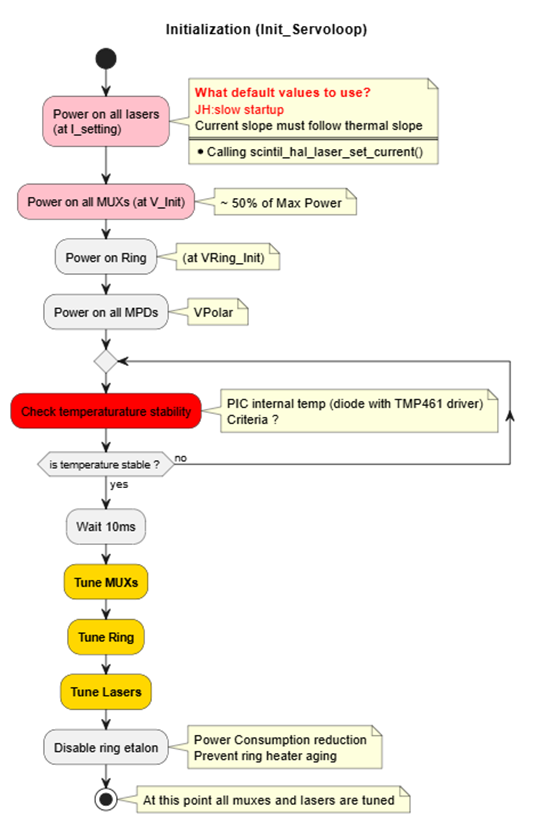

### 2.1.1 Configure system

In [ ]:

for module in modules:
    error = servoloop_configuration(
                api, 
                module, 
                configuration_params["Ilaser_setting"], 
                configuration_params["Vmuxheater_Init"], 
                configuration_params["Vring_Init"], 
                configuration_params["vpolar_las_init"], 
                configuration_params["vpolar_ring_init"],
                configuration_params["tec_setpoint"],
                configuration_params["temp_stability_channel"], 
                configuration_params["temp_stability_diff"], 
                configuration_params["temp_stability_timeout"]
            )
    assert error == scintil_hal_error_bit_t.SCINTIL_HAL_ERROR_NONE
# Split on two functions
# add different log module
# Add log file


INFO:root:Starting servoloop configuration...
INFO:root:Configuring TEC to 30°C
INFO:root:Setting lasers initial currents...
INFO:root:Lasers initial currents: {'SCINTIL_HAL_LASER_0': 0.1, 'SCINTIL_HAL_LASER_1': 0.1, 'SCINTIL_HAL_LASER_2': 0.1, 'SCINTIL_HAL_LASER_3': 0.1, 'SCINTIL_HAL_LASER_4': 0.1, 'SCINTIL_HAL_LASER_5': 0.1, 'SCINTIL_HAL_LASER_6': 0.1, 'SCINTIL_HAL_LASER_7': 0.1, 'SCINTIL_HAL_LASER_8': 0.1, 'SCINTIL_HAL_LASER_9': 0.1, 'SCINTIL_HAL_LASER_10': 0.1, 'SCINTIL_HAL_LASER_11': 0.1, 'SCINTIL_HAL_LASER_12': 0.1, 'SCINTIL_HAL_LASER_13': 0.1, 'SCINTIL_HAL_LASER_14': 0.1, 'SCINTIL_HAL_LASER_15': 0.1}
INFO:root:Setting mux heaters initial voltages...
INFO:root:Mux heaters initial voltages: {'SCINTIL_HAL_MUX_HEATER_BO_s31': 1.125, 'SCINTIL_HAL_MUX_HEATER_BO_s33': 1.125, 'SCINTIL_HAL_MUX_HEATER_BO_s32': 1.125, 'SCINTIL_HAL_MUX_HEATER_BO_s34': 1.125, 'SCINTIL_HAL_MUX_HEATER_BO_s21': 1.125, 'SCINTIL_HAL_MUX_HEATER_BO_s22': 1.125, 'SCINTIL_HAL_MUX_HEATER_BO_s11': 1.125, 'SCINTIL_HAL_M

Current temperature :35.125°C

INFO:root:Servoloop configuration completed successfully.
INFO:root:Configuration and temperature stability of MODULE_1 tooks 70.10332822799683s


### 2.1.2 Mux heater tuning

### a. One MUX

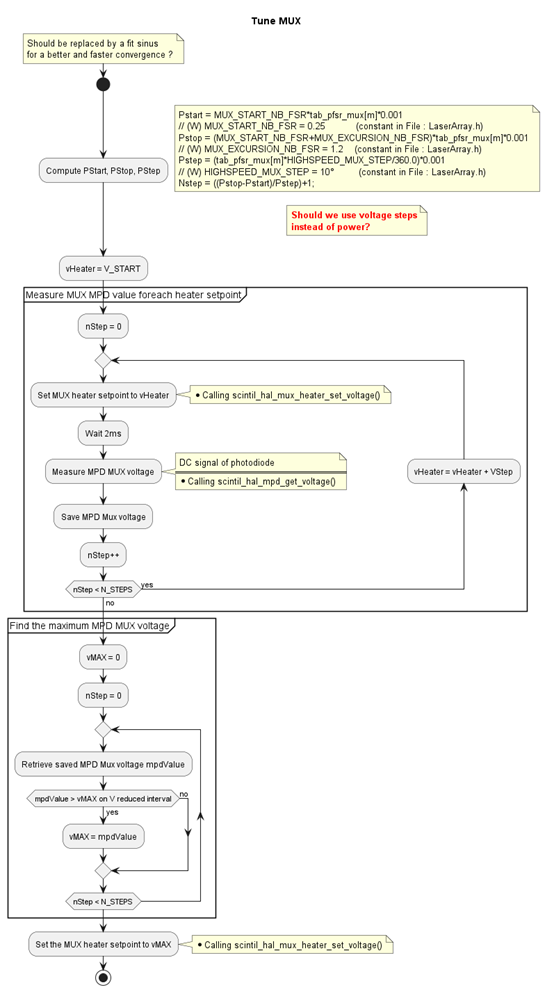

In [ ]:
for module in modules:
    for mux_heater in mux_heaters:
        error = servoloop_tune_mux(api, module, mux_heater, mux_tuning_params["Tune_Vstart"], mux_tuning_params["Tune_Vstop"], mux_tuning_params["Tune_Nsteps"])
        
        assert error == scintil_hal_error_bit_t.SCINTIL_HAL_ERROR_NONE
    # Add logs

### b. All muxes

INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_AE_s11
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939, 2.3949618994881736, 2.4270547995461498, 2.4587288382414196, 2.49]


Setting voltage :2.49 V

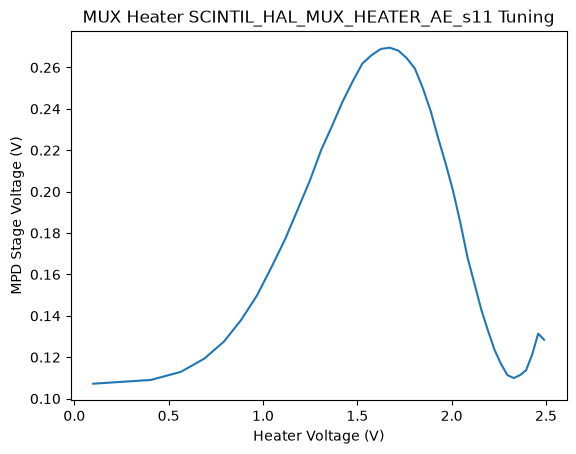

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_AE_s11 is: 1.67 V with MPD response: 0.270 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_AE_s22
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

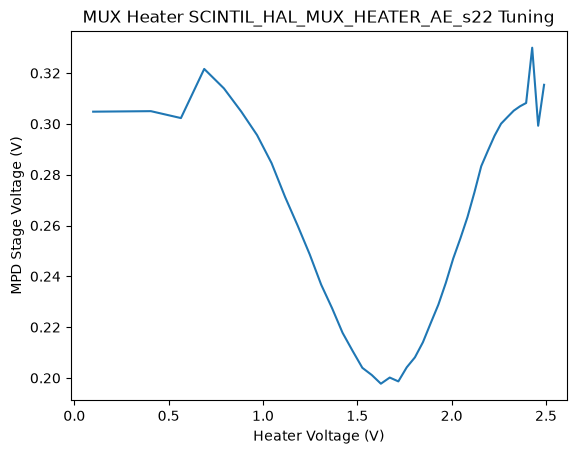

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_AE_s22 is: 2.43 V with MPD response: 0.330 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_AE_s21
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

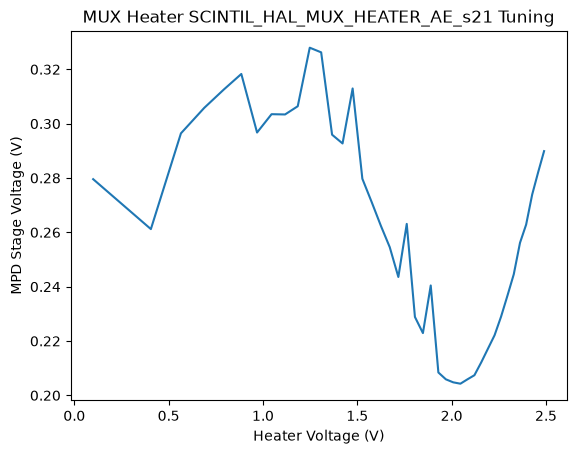

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_AE_s21 is: 1.25 V with MPD response: 0.328 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_AE_s34
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

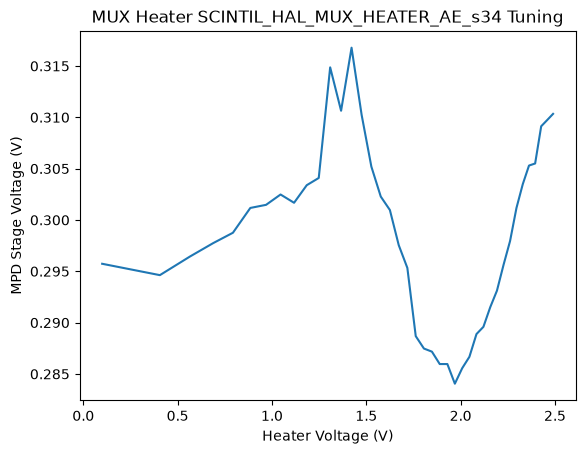

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_AE_s34 is: 1.42 V with MPD response: 0.317 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_AE_s32
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

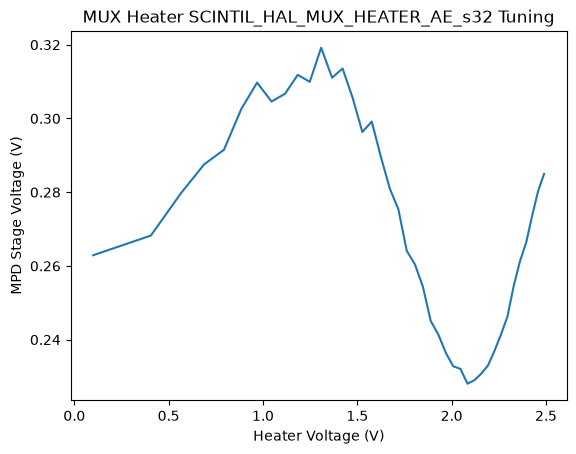

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_AE_s32 is: 1.31 V with MPD response: 0.319 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_AE_s33
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

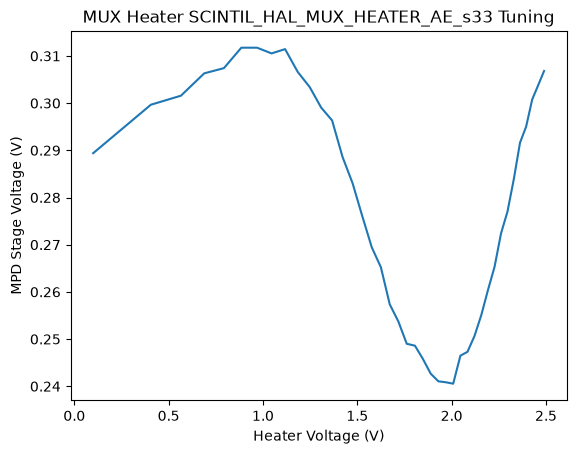

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_AE_s33 is: 0.89 V with MPD response: 0.312 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_AE_s31
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

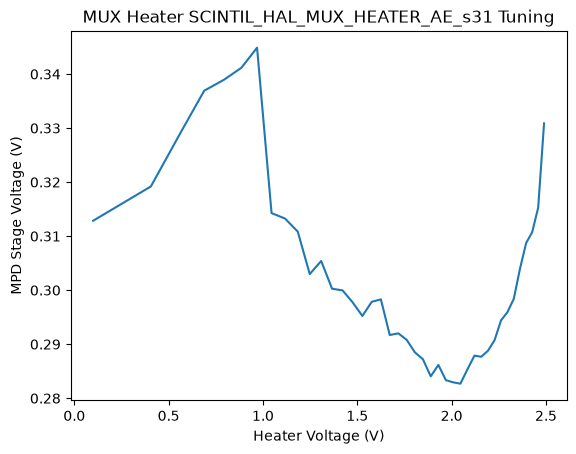

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_AE_s31 is: 0.97 V with MPD response: 0.345 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_BE_s11
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

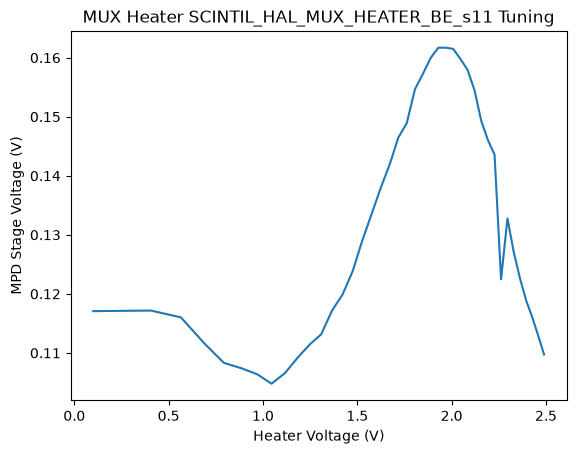

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_BE_s11 is: 1.93 V with MPD response: 0.162 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_BE_s22
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

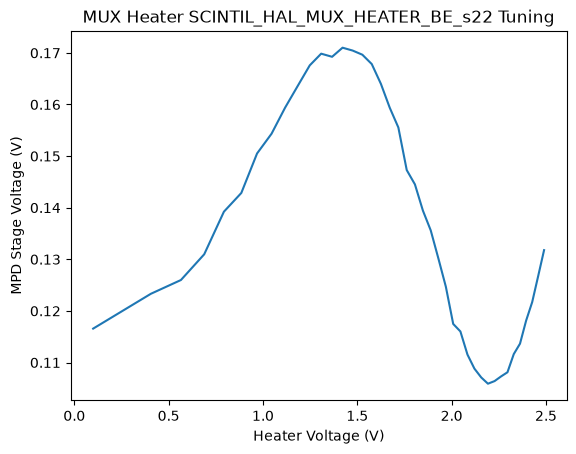

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_BE_s22 is: 1.42 V with MPD response: 0.171 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_BE_s21
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

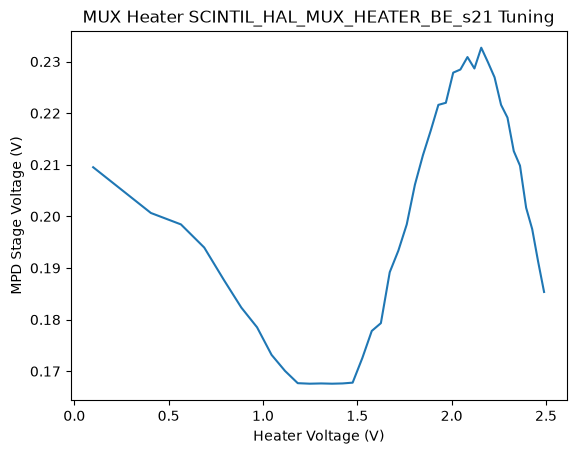

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_BE_s21 is: 2.16 V with MPD response: 0.233 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_BE_s34
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

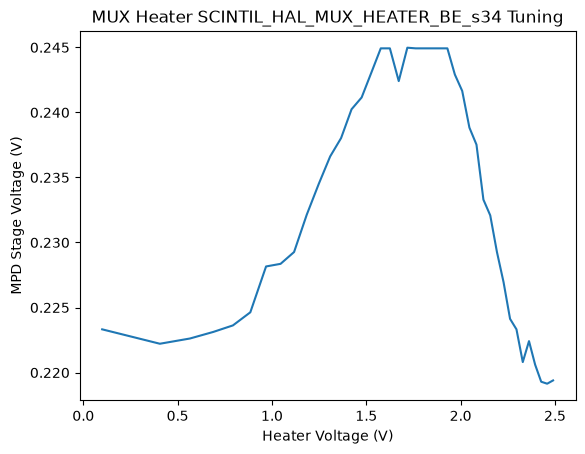

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_BE_s34 is: 1.72 V with MPD response: 0.245 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_BE_s32
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

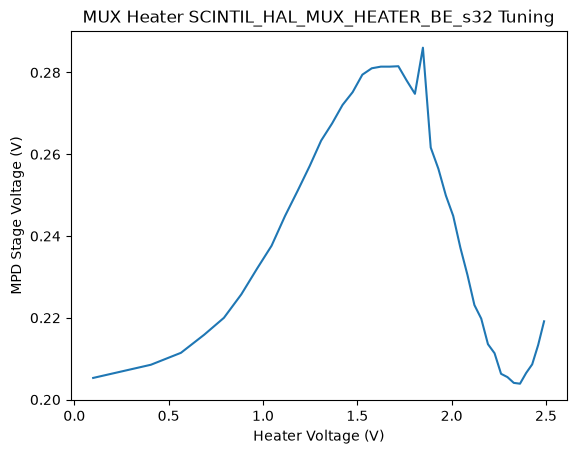

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_BE_s32 is: 1.85 V with MPD response: 0.286 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_BE_s33
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

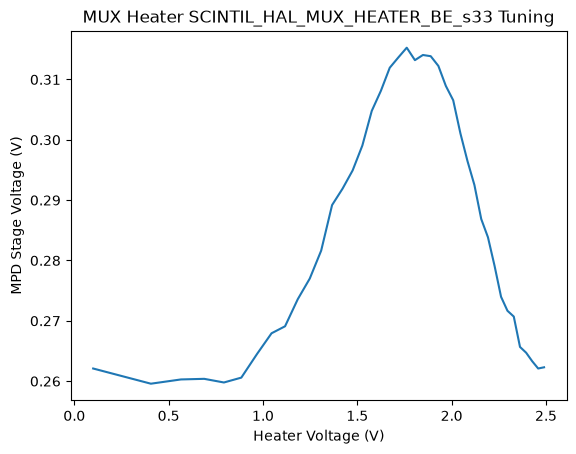

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_BE_s33 is: 1.76 V with MPD response: 0.315 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_BE_s31
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

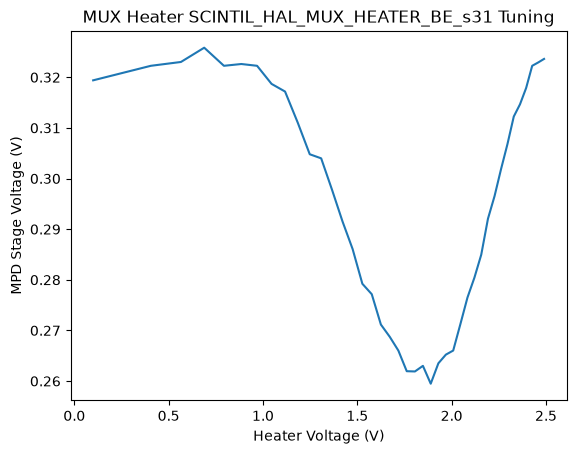

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_BE_s31 is: 0.69 V with MPD response: 0.326 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_AO_s11
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

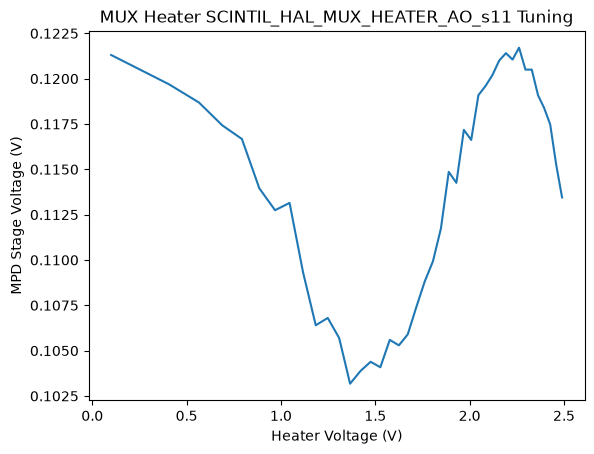

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_AO_s11 is: 2.26 V with MPD response: 0.122 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_AO_s22
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

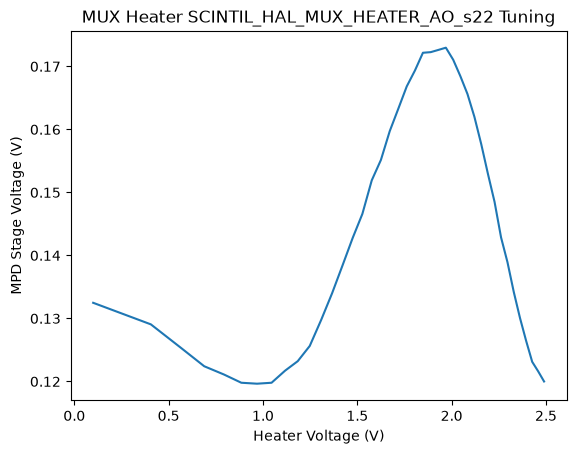

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_AO_s22 is: 1.97 V with MPD response: 0.173 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_AO_s21
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

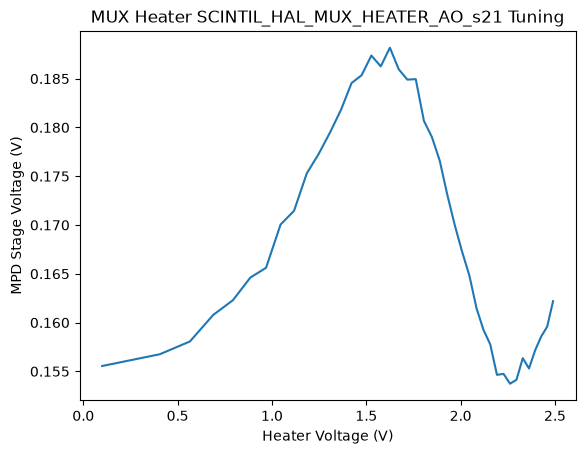

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_AO_s21 is: 1.63 V with MPD response: 0.188 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_AO_s34
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

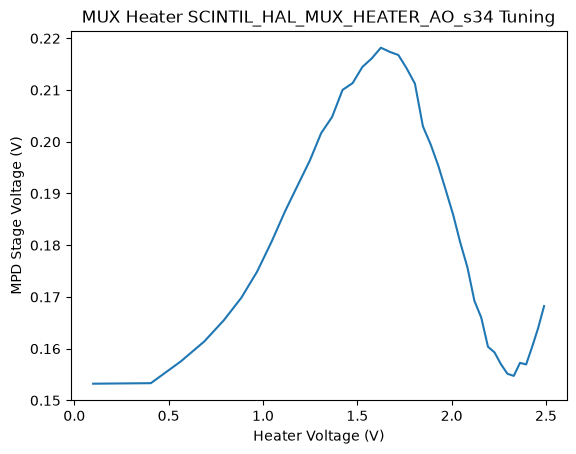

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_AO_s34 is: 1.63 V with MPD response: 0.218 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_AO_s32
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

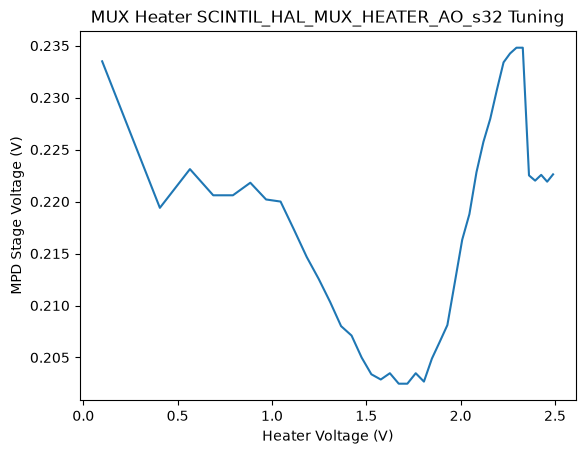

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_AO_s32 is: 2.30 V with MPD response: 0.235 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_AO_s33
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

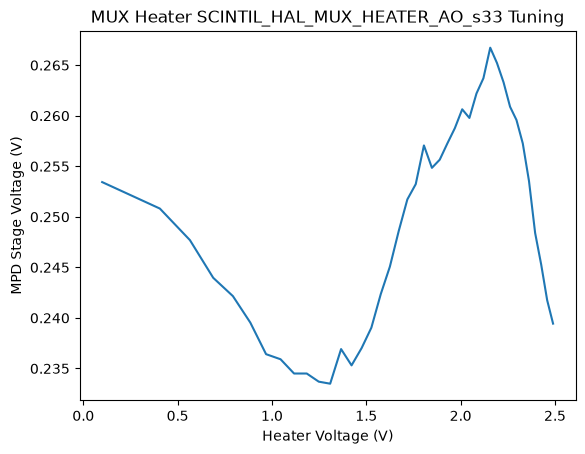

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_AO_s33 is: 2.16 V with MPD response: 0.267 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_AO_s31
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

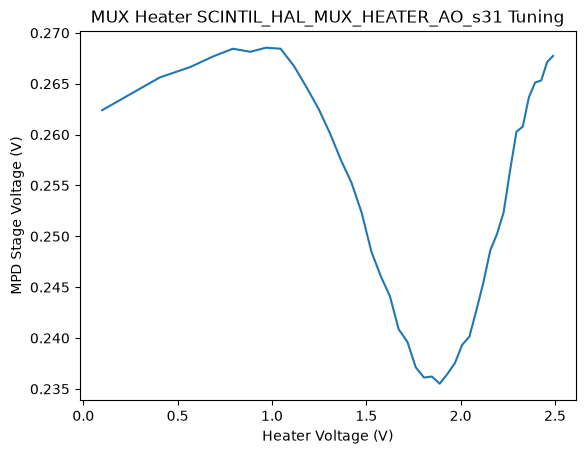

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_AO_s31 is: 0.97 V with MPD response: 0.269 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_BO_s11
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

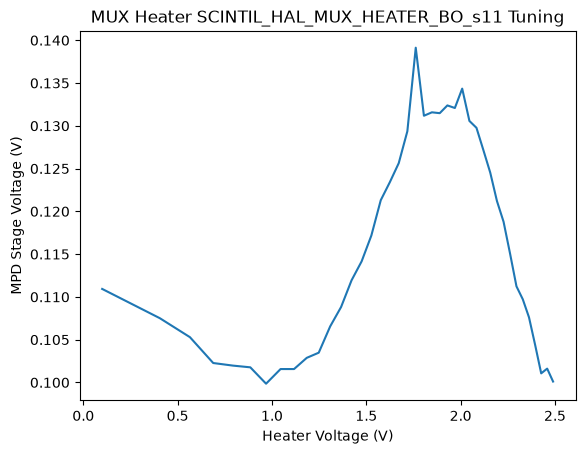

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_BO_s11 is: 1.76 V with MPD response: 0.139 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_BO_s22
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

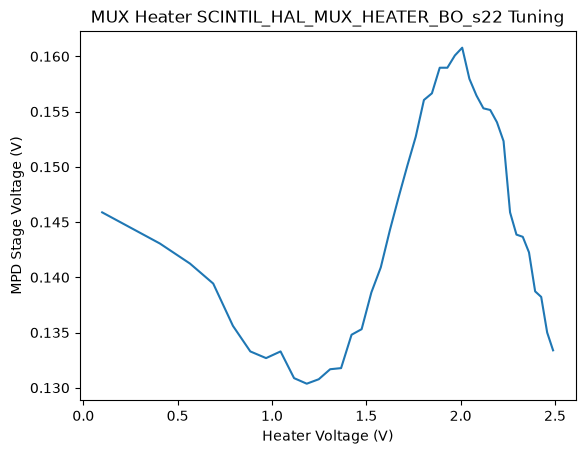

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_BO_s22 is: 2.01 V with MPD response: 0.161 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_BO_s21
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

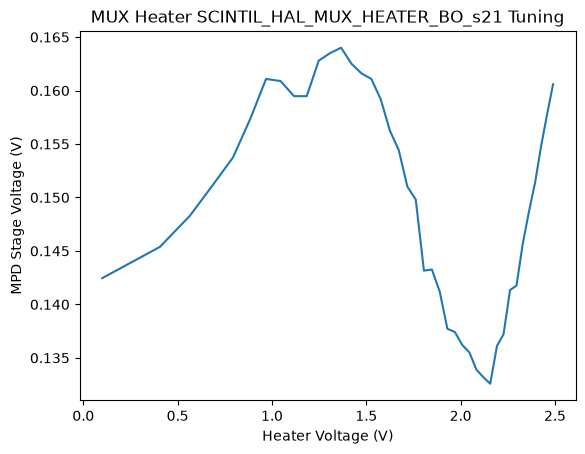

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_BO_s21 is: 1.37 V with MPD response: 0.164 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_BO_s34
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

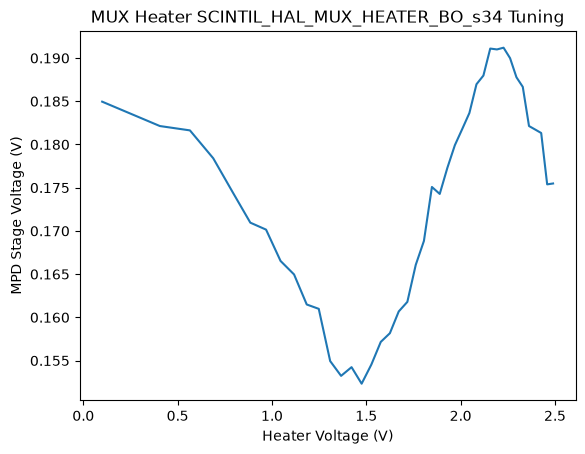

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_BO_s34 is: 2.23 V with MPD response: 0.191 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_BO_s32
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

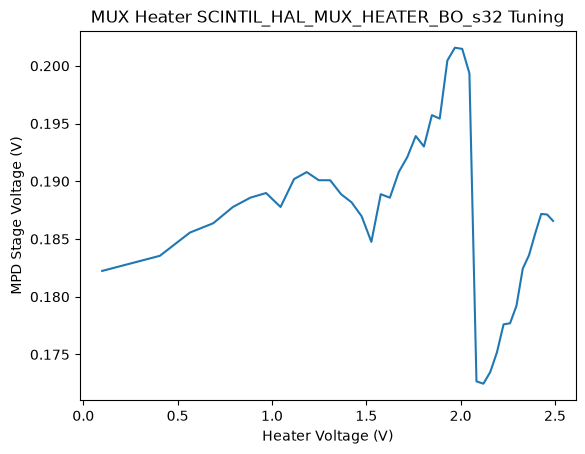

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_BO_s32 is: 1.97 V with MPD response: 0.202 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_BO_s33
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

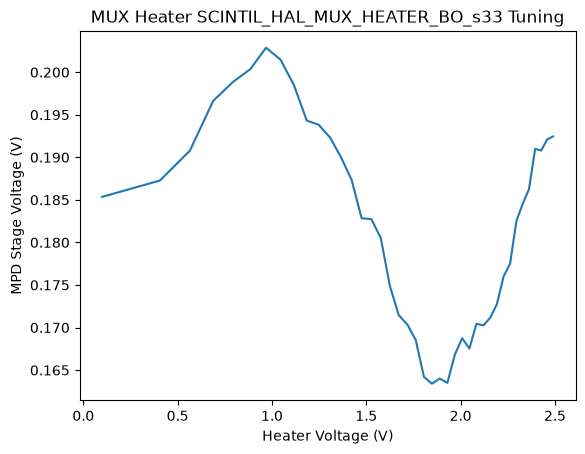

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_BO_s33 is: 0.97 V with MPD response: 0.203 V
INFO:root:Start Tuning MUX: SCINTIL_HAL_MUX_HEATER_BO_s31
INFO:root:Starting voltage: 0.1 V
INFO:root:Stopping voltage: 2.49 V
INFO:root:Nbs steps: 41
INFO:root:Heater sweep data: [0.1, 0.40589715446157054, 0.5652477332993031, 0.6886635608190693, 0.7931015067442504, 0.885303620234324, 0.9687698385065464, 1.0455943285997682, 1.117148154901578, 1.184386972235004, 1.2480084134331788, 1.3085402171886045, 1.366393062043276, 1.4218939833897604, 1.475308442326553, 1.526855428650663, 1.5767181105067578, 1.6250515376442682, 1.6719883372798987, 1.7176430071467121, 1.7621152062223402, 1.8054923151318039, 1.8478514550688323, 1.8892610989484753, 1.929782371149659, 1.9694701063991809, 2.0083737202024925, 2.0465379302617386, 2.084003358922437, 2.1208070397846197, 2.1569828464779226, 2.1925618577362878, 2.227572669970612, 2.262041666282918, 2.2959932491189954, 2.3294500423919806, 2.362433067834939

Setting voltage :2.49 V

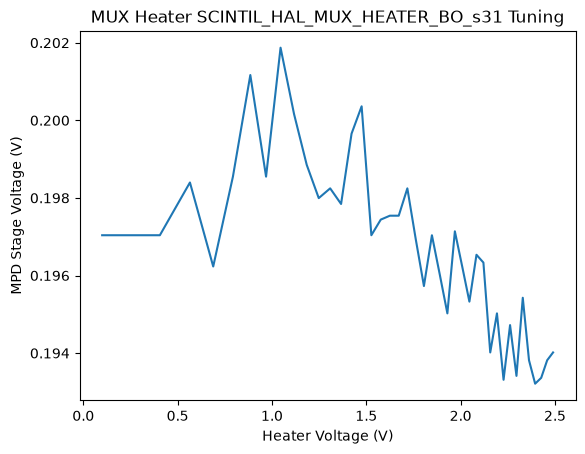

INFO:root:Best Heater voltage for MUX SCINTIL_HAL_MUX_HEATER_BO_s31 is: 1.05 V with MPD response: 0.202 V
INFO:root:Tuning of all Muxes tooks 141.86409759521484s


<scintil_hal_error_bit_t.SCINTIL_HAL_ERROR_NONE: 0>

In [7]:
servoloop_tune_muxes(api, modules[0], mux_tuning_params["Tune_Vstart"], mux_tuning_params["Tune_Vstop"], mux_tuning_params["Tune_Nsteps"], 0.1)

### 2.1.3 Ring heater tuning

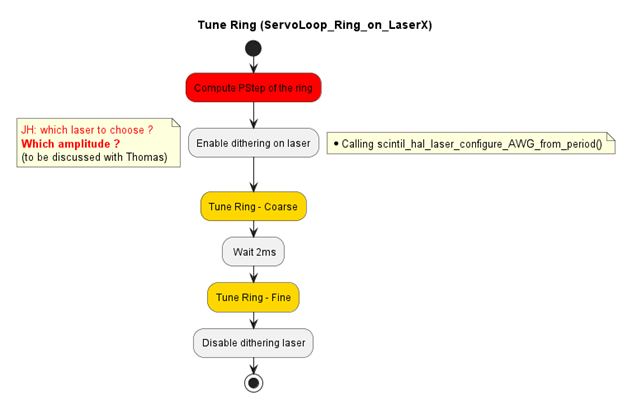

### a. One reference laser

#### 2.1.3.1 Enabling dithering on Laser X

In [ ]:
# Enable dithering on Laser X
laser_ref = scintil_hal_laser_t.SCINTIL_HAL_LASER_2
dithering_frequency = laser_dithering_params["d_frequency"][laser_ref.name]
dithering_amplitude = laser_dithering_params["d_amplitude"][laser_ref.name]
fft_bin = int((dithering_frequency / FFT_FS) * FFT_SIZE)
for module in modules:
    error = servoloop_laser_enable_dithering(api, module, laser_ref, dithering_frequency, dithering_amplitude)
    
    assert error == scintil_hal_error_bit_t.SCINTIL_HAL_ERROR_NONE

#### 2.1.3.2 Coarse tuning of ring

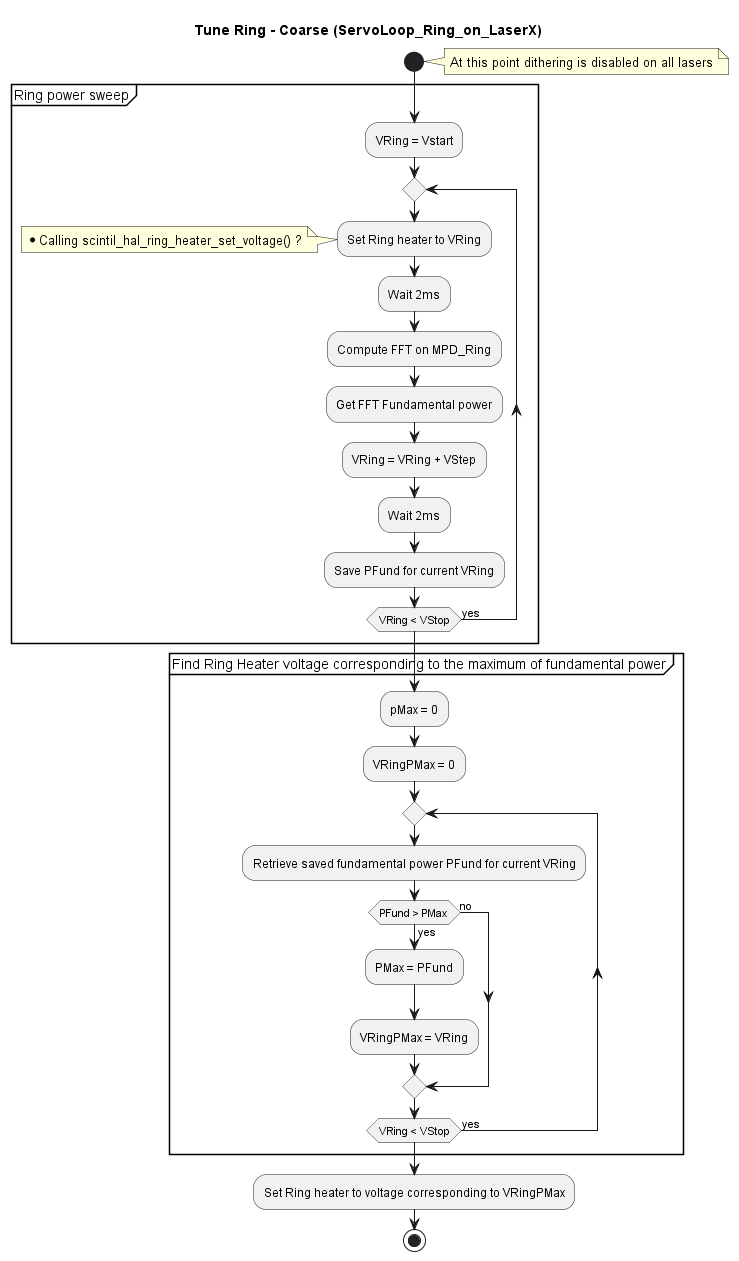

In [ ]:
# Coarse tuning parameters
ring_resistance = 35 # Ohms
coarse_v_start = math.sqrt(ring_tuning_params["coarse_tuning"]["Tune_Pstart"] * ring_resistance)
coarse_v_stop = math.sqrt(ring_tuning_params["coarse_tuning"]["Tune_Pstop"] * ring_resistance)
coarse_n_step = ring_tuning_params["coarse_tuning"]["Tune_Nsteps"]

for module in modules:
    error = servoloop_tune_ring_coarse(api, module, coarse_v_start, coarse_v_stop, coarse_n_step, fft_bin)
    assert error == scintil_hal_error_bit_t.SCINTIL_HAL_ERROR_NONE

#### 2.1.3.3 Fine tuning of ring

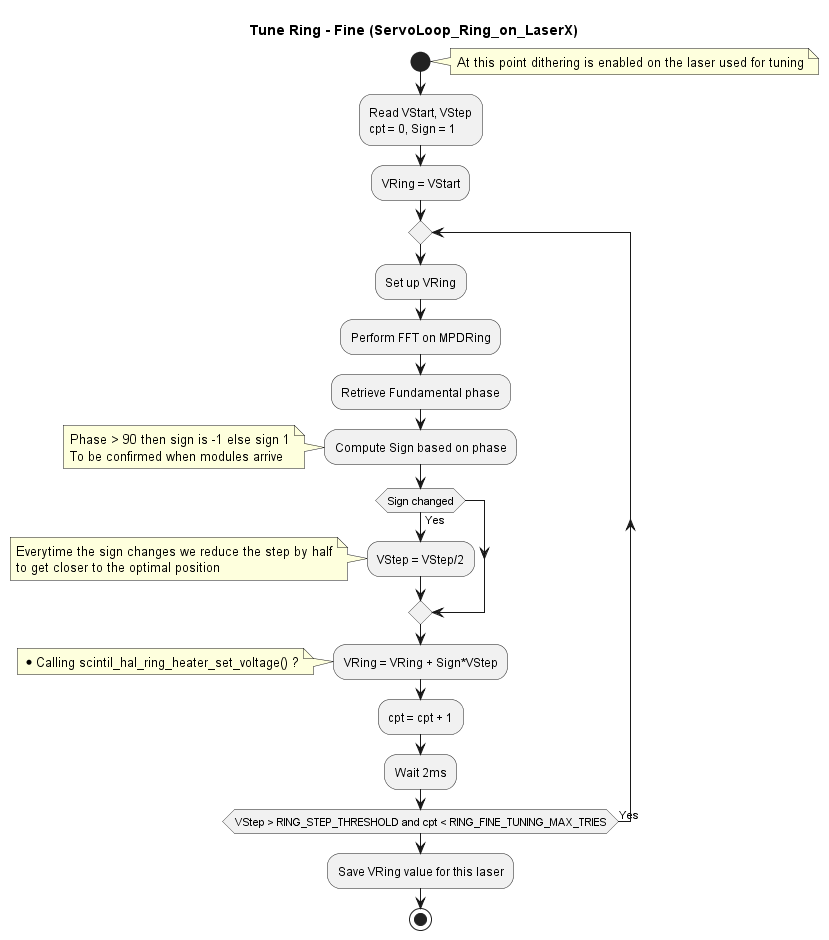

#### 2.1.3.4 Disable tuning on Laser X

In [ ]:
ret = api.scintil_hal_laser_set_dither_state(module, laser_ref, False)

assert ret["errcode"] == scintil_hal_error_bit_t.SCINTIL_HAL_ERROR_NONE

### b. All lasers

INFO:root:Enable dithering on Laser SCINTIL_HAL_LASER_0 with frequency 9765.625 Hz and amplitude 0.006 A
INFO:root:Start Tuning RING
INFO:root:Starting voltage: 1.1318127053536728 V
INFO:root:Stopping voltage: 2.083266665599966 V
INFO:root:Nbs steps: 25
INFO:root:Heater sweep data: [1.1318127053536728, 1.186784872389825, 1.2393210506832628, 1.2897189616346656, 1.3382202110763883, 1.3850240671795804, 1.4302971719191784, 1.4741805633413205, 1.5167948663766853, 1.558244204224742, 1.5986191958478835, 1.637999287749133, 1.676454592286949, 1.7140473544605859, 1.750833135015061, 1.7868617741728094, 1.822178183749694, 1.856823003591529, 1.8908331496988304, 1.9242422751133321, 1.9570811599590516, 1.9893780435100816, 2.0211589084813033, 2.052447725684303, 2.083266665599966]


Setting voltage :2.08 V

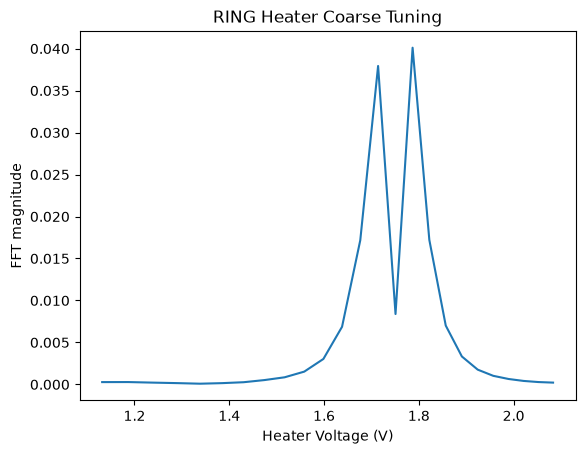

INFO:root:Best Heater voltage for RING is: 1.79 V with fft magnitude: 0.040 V
INFO:root:Enable dithering on Laser SCINTIL_HAL_LASER_1 with frequency 10375.97656 Hz and amplitude 0.006 A
INFO:root:Start Tuning RING
INFO:root:Starting voltage: 1.1318127053536728 V
INFO:root:Stopping voltage: 2.083266665599966 V
INFO:root:Nbs steps: 25
INFO:root:Heater sweep data: [1.1318127053536728, 1.186784872389825, 1.2393210506832628, 1.2897189616346656, 1.3382202110763883, 1.3850240671795804, 1.4302971719191784, 1.4741805633413205, 1.5167948663766853, 1.558244204224742, 1.5986191958478835, 1.637999287749133, 1.676454592286949, 1.7140473544605859, 1.750833135015061, 1.7868617741728094, 1.822178183749694, 1.856823003591529, 1.8908331496988304, 1.9242422751133321, 1.9570811599590516, 1.9893780435100816, 2.0211589084813033, 2.052447725684303, 2.083266665599966]


Setting voltage :2.08 V

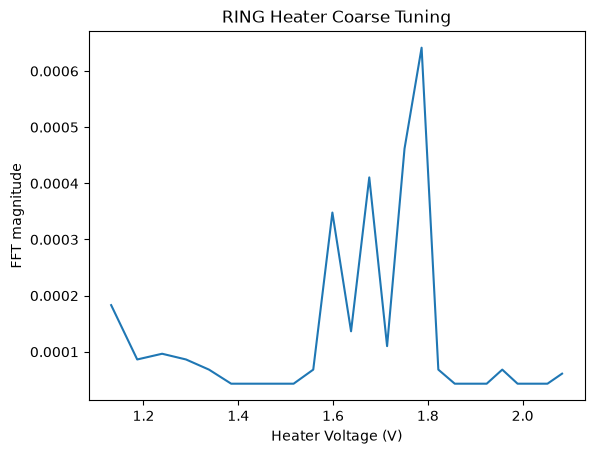

INFO:root:Best Heater voltage for RING is: 1.79 V with fft magnitude: 0.001 V
INFO:root:Enable dithering on Laser SCINTIL_HAL_LASER_2 with frequency 10986.32813 Hz and amplitude 0.006 A
INFO:root:Start Tuning RING
INFO:root:Starting voltage: 1.1318127053536728 V
INFO:root:Stopping voltage: 2.083266665599966 V
INFO:root:Nbs steps: 25
INFO:root:Heater sweep data: [1.1318127053536728, 1.186784872389825, 1.2393210506832628, 1.2897189616346656, 1.3382202110763883, 1.3850240671795804, 1.4302971719191784, 1.4741805633413205, 1.5167948663766853, 1.558244204224742, 1.5986191958478835, 1.637999287749133, 1.676454592286949, 1.7140473544605859, 1.750833135015061, 1.7868617741728094, 1.822178183749694, 1.856823003591529, 1.8908331496988304, 1.9242422751133321, 1.9570811599590516, 1.9893780435100816, 2.0211589084813033, 2.052447725684303, 2.083266665599966]


Setting voltage :2.08 V

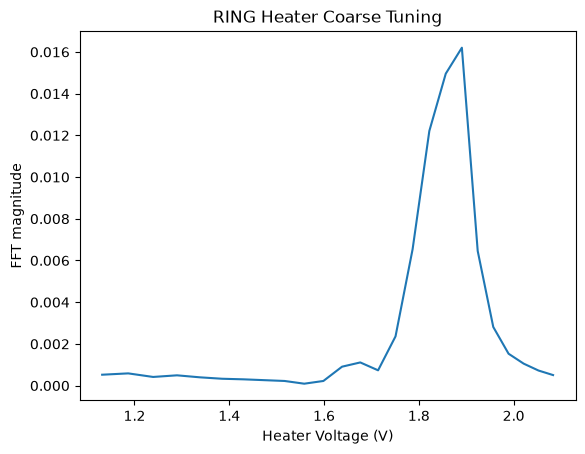

INFO:root:Best Heater voltage for RING is: 1.89 V with fft magnitude: 0.016 V
INFO:root:Enable dithering on Laser SCINTIL_HAL_LASER_3 with frequency 11596.67969 Hz and amplitude 0.006 A
INFO:root:Start Tuning RING
INFO:root:Starting voltage: 1.1318127053536728 V
INFO:root:Stopping voltage: 2.083266665599966 V
INFO:root:Nbs steps: 25
INFO:root:Heater sweep data: [1.1318127053536728, 1.186784872389825, 1.2393210506832628, 1.2897189616346656, 1.3382202110763883, 1.3850240671795804, 1.4302971719191784, 1.4741805633413205, 1.5167948663766853, 1.558244204224742, 1.5986191958478835, 1.637999287749133, 1.676454592286949, 1.7140473544605859, 1.750833135015061, 1.7868617741728094, 1.822178183749694, 1.856823003591529, 1.8908331496988304, 1.9242422751133321, 1.9570811599590516, 1.9893780435100816, 2.0211589084813033, 2.052447725684303, 2.083266665599966]


Setting voltage :2.08 V

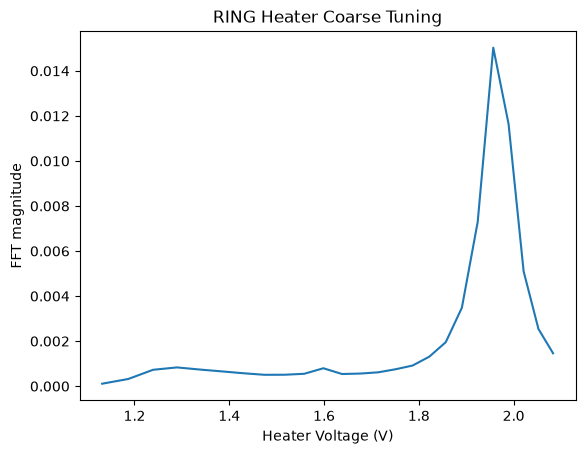

INFO:root:Best Heater voltage for RING is: 1.96 V with fft magnitude: 0.015 V
INFO:root:Enable dithering on Laser SCINTIL_HAL_LASER_4 with frequency 12207.03125 Hz and amplitude 0.006 A
INFO:root:Start Tuning RING
INFO:root:Starting voltage: 1.1318127053536728 V
INFO:root:Stopping voltage: 2.083266665599966 V
INFO:root:Nbs steps: 25
INFO:root:Heater sweep data: [1.1318127053536728, 1.186784872389825, 1.2393210506832628, 1.2897189616346656, 1.3382202110763883, 1.3850240671795804, 1.4302971719191784, 1.4741805633413205, 1.5167948663766853, 1.558244204224742, 1.5986191958478835, 1.637999287749133, 1.676454592286949, 1.7140473544605859, 1.750833135015061, 1.7868617741728094, 1.822178183749694, 1.856823003591529, 1.8908331496988304, 1.9242422751133321, 1.9570811599590516, 1.9893780435100816, 2.0211589084813033, 2.052447725684303, 2.083266665599966]


Setting voltage :2.08 V

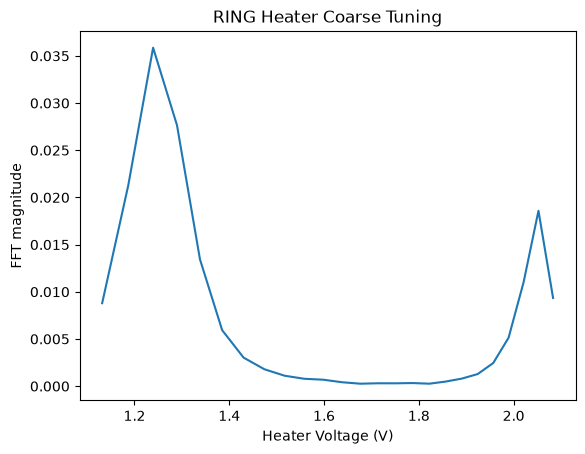

INFO:root:Best Heater voltage for RING is: 1.24 V with fft magnitude: 0.036 V
INFO:root:Enable dithering on Laser SCINTIL_HAL_LASER_5 with frequency 12817.38281 Hz and amplitude 0.006 A
INFO:root:Start Tuning RING
INFO:root:Starting voltage: 1.1318127053536728 V
INFO:root:Stopping voltage: 2.083266665599966 V
INFO:root:Nbs steps: 25
INFO:root:Heater sweep data: [1.1318127053536728, 1.186784872389825, 1.2393210506832628, 1.2897189616346656, 1.3382202110763883, 1.3850240671795804, 1.4302971719191784, 1.4741805633413205, 1.5167948663766853, 1.558244204224742, 1.5986191958478835, 1.637999287749133, 1.676454592286949, 1.7140473544605859, 1.750833135015061, 1.7868617741728094, 1.822178183749694, 1.856823003591529, 1.8908331496988304, 1.9242422751133321, 1.9570811599590516, 1.9893780435100816, 2.0211589084813033, 2.052447725684303, 2.083266665599966]


Setting voltage :2.08 V

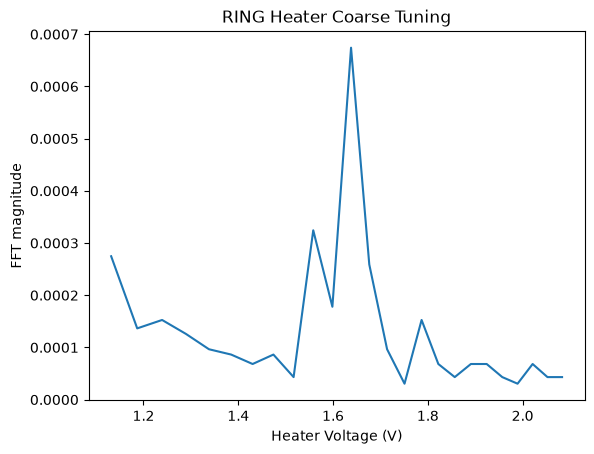

INFO:root:Best Heater voltage for RING is: 1.64 V with fft magnitude: 0.001 V
INFO:root:Enable dithering on Laser SCINTIL_HAL_LASER_6 with frequency 13427.73438 Hz and amplitude 0.006 A
INFO:root:Start Tuning RING
INFO:root:Starting voltage: 1.1318127053536728 V
INFO:root:Stopping voltage: 2.083266665599966 V
INFO:root:Nbs steps: 25
INFO:root:Heater sweep data: [1.1318127053536728, 1.186784872389825, 1.2393210506832628, 1.2897189616346656, 1.3382202110763883, 1.3850240671795804, 1.4302971719191784, 1.4741805633413205, 1.5167948663766853, 1.558244204224742, 1.5986191958478835, 1.637999287749133, 1.676454592286949, 1.7140473544605859, 1.750833135015061, 1.7868617741728094, 1.822178183749694, 1.856823003591529, 1.8908331496988304, 1.9242422751133321, 1.9570811599590516, 1.9893780435100816, 2.0211589084813033, 2.052447725684303, 2.083266665599966]


Setting voltage :2.08 V

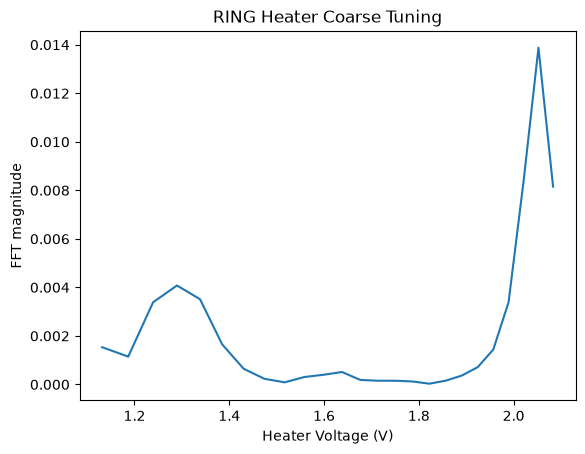

INFO:root:Best Heater voltage for RING is: 2.05 V with fft magnitude: 0.014 V
INFO:root:Enable dithering on Laser SCINTIL_HAL_LASER_7 with frequency 14038.08594 Hz and amplitude 0.006 A
INFO:root:Start Tuning RING
INFO:root:Starting voltage: 1.1318127053536728 V
INFO:root:Stopping voltage: 2.083266665599966 V
INFO:root:Nbs steps: 25
INFO:root:Heater sweep data: [1.1318127053536728, 1.186784872389825, 1.2393210506832628, 1.2897189616346656, 1.3382202110763883, 1.3850240671795804, 1.4302971719191784, 1.4741805633413205, 1.5167948663766853, 1.558244204224742, 1.5986191958478835, 1.637999287749133, 1.676454592286949, 1.7140473544605859, 1.750833135015061, 1.7868617741728094, 1.822178183749694, 1.856823003591529, 1.8908331496988304, 1.9242422751133321, 1.9570811599590516, 1.9893780435100816, 2.0211589084813033, 2.052447725684303, 2.083266665599966]


Setting voltage :2.08 V

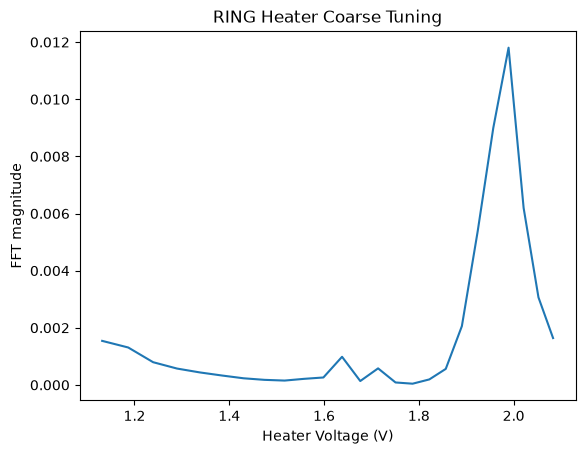

INFO:root:Best Heater voltage for RING is: 1.99 V with fft magnitude: 0.012 V
INFO:root:Enable dithering on Laser SCINTIL_HAL_LASER_8 with frequency 14648.4375 Hz and amplitude 0.006 A
INFO:root:Start Tuning RING
INFO:root:Starting voltage: 1.1318127053536728 V
INFO:root:Stopping voltage: 2.083266665599966 V
INFO:root:Nbs steps: 25
INFO:root:Heater sweep data: [1.1318127053536728, 1.186784872389825, 1.2393210506832628, 1.2897189616346656, 1.3382202110763883, 1.3850240671795804, 1.4302971719191784, 1.4741805633413205, 1.5167948663766853, 1.558244204224742, 1.5986191958478835, 1.637999287749133, 1.676454592286949, 1.7140473544605859, 1.750833135015061, 1.7868617741728094, 1.822178183749694, 1.856823003591529, 1.8908331496988304, 1.9242422751133321, 1.9570811599590516, 1.9893780435100816, 2.0211589084813033, 2.052447725684303, 2.083266665599966]


Setting voltage :2.08 V

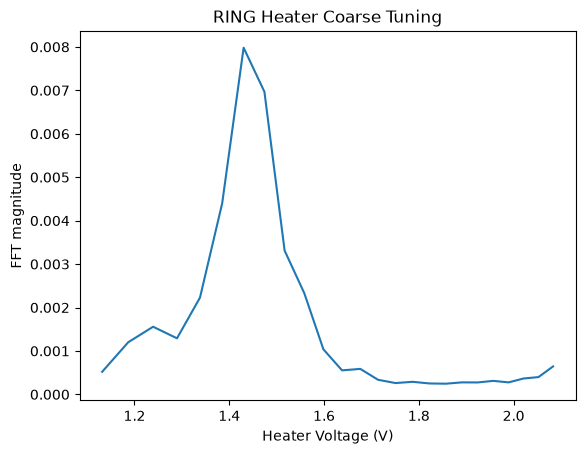

INFO:root:Best Heater voltage for RING is: 1.43 V with fft magnitude: 0.008 V
INFO:root:Enable dithering on Laser SCINTIL_HAL_LASER_9 with frequency 15258.78906 Hz and amplitude 0.006 A
INFO:root:Start Tuning RING
INFO:root:Starting voltage: 1.1318127053536728 V
INFO:root:Stopping voltage: 2.083266665599966 V
INFO:root:Nbs steps: 25
INFO:root:Heater sweep data: [1.1318127053536728, 1.186784872389825, 1.2393210506832628, 1.2897189616346656, 1.3382202110763883, 1.3850240671795804, 1.4302971719191784, 1.4741805633413205, 1.5167948663766853, 1.558244204224742, 1.5986191958478835, 1.637999287749133, 1.676454592286949, 1.7140473544605859, 1.750833135015061, 1.7868617741728094, 1.822178183749694, 1.856823003591529, 1.8908331496988304, 1.9242422751133321, 1.9570811599590516, 1.9893780435100816, 2.0211589084813033, 2.052447725684303, 2.083266665599966]


Setting voltage :2.08 V

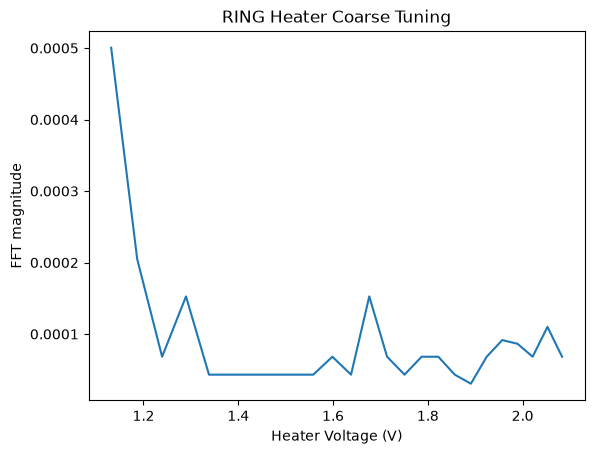

INFO:root:Best Heater voltage for RING is: 1.13 V with fft magnitude: 0.001 V
INFO:root:Enable dithering on Laser SCINTIL_HAL_LASER_10 with frequency 15869.14063 Hz and amplitude 0.006 A
INFO:root:Start Tuning RING
INFO:root:Starting voltage: 1.1318127053536728 V
INFO:root:Stopping voltage: 2.083266665599966 V
INFO:root:Nbs steps: 25
INFO:root:Heater sweep data: [1.1318127053536728, 1.186784872389825, 1.2393210506832628, 1.2897189616346656, 1.3382202110763883, 1.3850240671795804, 1.4302971719191784, 1.4741805633413205, 1.5167948663766853, 1.558244204224742, 1.5986191958478835, 1.637999287749133, 1.676454592286949, 1.7140473544605859, 1.750833135015061, 1.7868617741728094, 1.822178183749694, 1.856823003591529, 1.8908331496988304, 1.9242422751133321, 1.9570811599590516, 1.9893780435100816, 2.0211589084813033, 2.052447725684303, 2.083266665599966]


Setting voltage :2.08 V

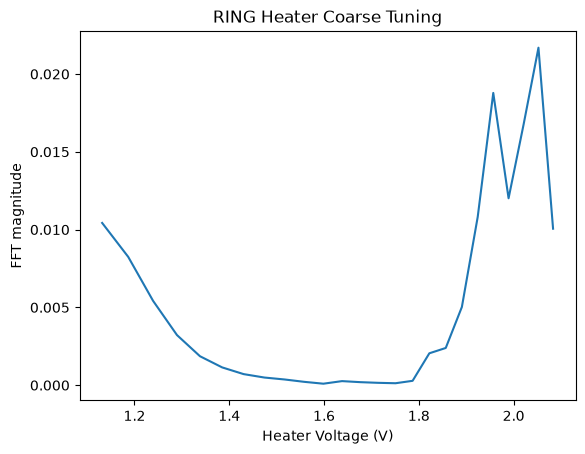

INFO:root:Best Heater voltage for RING is: 2.05 V with fft magnitude: 0.022 V
INFO:root:Enable dithering on Laser SCINTIL_HAL_LASER_11 with frequency 16479.49219 Hz and amplitude 0.006 A
INFO:root:Start Tuning RING
INFO:root:Starting voltage: 1.1318127053536728 V
INFO:root:Stopping voltage: 2.083266665599966 V
INFO:root:Nbs steps: 25
INFO:root:Heater sweep data: [1.1318127053536728, 1.186784872389825, 1.2393210506832628, 1.2897189616346656, 1.3382202110763883, 1.3850240671795804, 1.4302971719191784, 1.4741805633413205, 1.5167948663766853, 1.558244204224742, 1.5986191958478835, 1.637999287749133, 1.676454592286949, 1.7140473544605859, 1.750833135015061, 1.7868617741728094, 1.822178183749694, 1.856823003591529, 1.8908331496988304, 1.9242422751133321, 1.9570811599590516, 1.9893780435100816, 2.0211589084813033, 2.052447725684303, 2.083266665599966]


Setting voltage :2.08 V

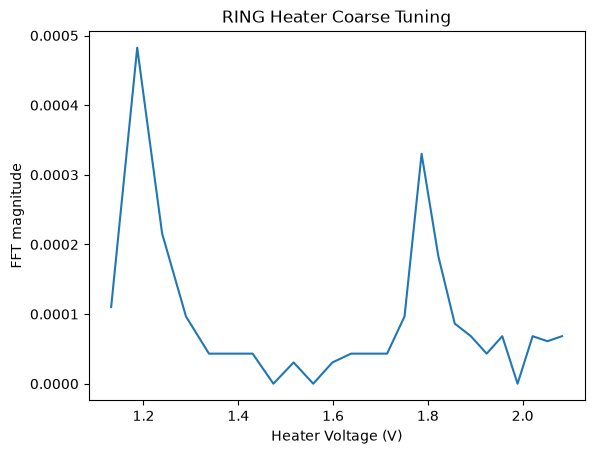

INFO:root:Best Heater voltage for RING is: 1.19 V with fft magnitude: 0.000 V
INFO:root:Enable dithering on Laser SCINTIL_HAL_LASER_12 with frequency 17089.84375 Hz and amplitude 0.006 A
INFO:root:Start Tuning RING
INFO:root:Starting voltage: 1.1318127053536728 V
INFO:root:Stopping voltage: 2.083266665599966 V
INFO:root:Nbs steps: 25
INFO:root:Heater sweep data: [1.1318127053536728, 1.186784872389825, 1.2393210506832628, 1.2897189616346656, 1.3382202110763883, 1.3850240671795804, 1.4302971719191784, 1.4741805633413205, 1.5167948663766853, 1.558244204224742, 1.5986191958478835, 1.637999287749133, 1.676454592286949, 1.7140473544605859, 1.750833135015061, 1.7868617741728094, 1.822178183749694, 1.856823003591529, 1.8908331496988304, 1.9242422751133321, 1.9570811599590516, 1.9893780435100816, 2.0211589084813033, 2.052447725684303, 2.083266665599966]


Setting voltage :2.08 V

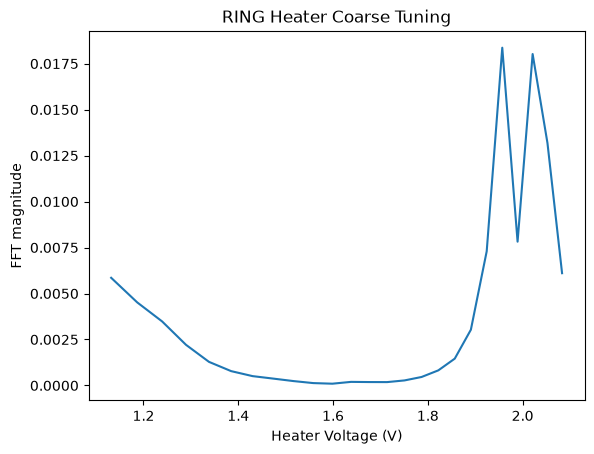

INFO:root:Best Heater voltage for RING is: 1.96 V with fft magnitude: 0.018 V
INFO:root:Enable dithering on Laser SCINTIL_HAL_LASER_13 with frequency 17700.19531 Hz and amplitude 0.006 A
INFO:root:Start Tuning RING
INFO:root:Starting voltage: 1.1318127053536728 V
INFO:root:Stopping voltage: 2.083266665599966 V
INFO:root:Nbs steps: 25
INFO:root:Heater sweep data: [1.1318127053536728, 1.186784872389825, 1.2393210506832628, 1.2897189616346656, 1.3382202110763883, 1.3850240671795804, 1.4302971719191784, 1.4741805633413205, 1.5167948663766853, 1.558244204224742, 1.5986191958478835, 1.637999287749133, 1.676454592286949, 1.7140473544605859, 1.750833135015061, 1.7868617741728094, 1.822178183749694, 1.856823003591529, 1.8908331496988304, 1.9242422751133321, 1.9570811599590516, 1.9893780435100816, 2.0211589084813033, 2.052447725684303, 2.083266665599966]


Setting voltage :2.08 V

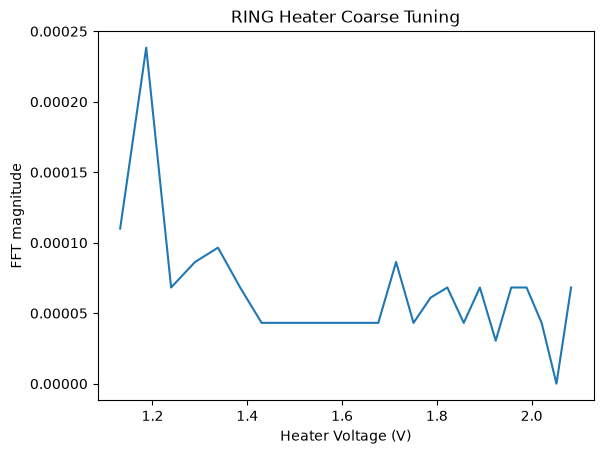

INFO:root:Best Heater voltage for RING is: 1.19 V with fft magnitude: 0.000 V
INFO:root:Enable dithering on Laser SCINTIL_HAL_LASER_14 with frequency 18310.54688 Hz and amplitude 0.006 A
INFO:root:Start Tuning RING
INFO:root:Starting voltage: 1.1318127053536728 V
INFO:root:Stopping voltage: 2.083266665599966 V
INFO:root:Nbs steps: 25
INFO:root:Heater sweep data: [1.1318127053536728, 1.186784872389825, 1.2393210506832628, 1.2897189616346656, 1.3382202110763883, 1.3850240671795804, 1.4302971719191784, 1.4741805633413205, 1.5167948663766853, 1.558244204224742, 1.5986191958478835, 1.637999287749133, 1.676454592286949, 1.7140473544605859, 1.750833135015061, 1.7868617741728094, 1.822178183749694, 1.856823003591529, 1.8908331496988304, 1.9242422751133321, 1.9570811599590516, 1.9893780435100816, 2.0211589084813033, 2.052447725684303, 2.083266665599966]


Setting voltage :2.08 V

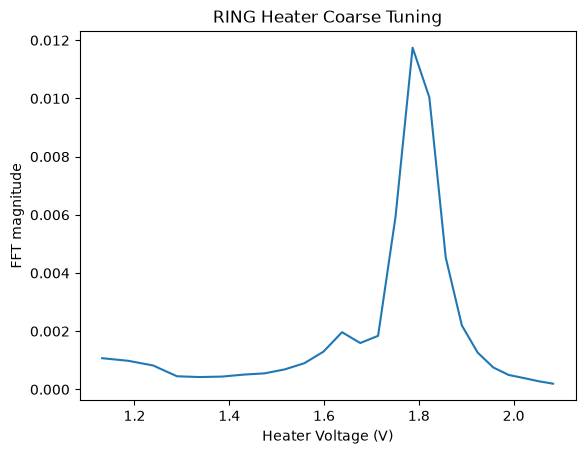

INFO:root:Best Heater voltage for RING is: 1.79 V with fft magnitude: 0.012 V
INFO:root:Enable dithering on Laser SCINTIL_HAL_LASER_15 with frequency 18920.89844 Hz and amplitude 0.006 A
INFO:root:Start Tuning RING
INFO:root:Starting voltage: 1.1318127053536728 V
INFO:root:Stopping voltage: 2.083266665599966 V
INFO:root:Nbs steps: 25
INFO:root:Heater sweep data: [1.1318127053536728, 1.186784872389825, 1.2393210506832628, 1.2897189616346656, 1.3382202110763883, 1.3850240671795804, 1.4302971719191784, 1.4741805633413205, 1.5167948663766853, 1.558244204224742, 1.5986191958478835, 1.637999287749133, 1.676454592286949, 1.7140473544605859, 1.750833135015061, 1.7868617741728094, 1.822178183749694, 1.856823003591529, 1.8908331496988304, 1.9242422751133321, 1.9570811599590516, 1.9893780435100816, 2.0211589084813033, 2.052447725684303, 2.083266665599966]


Setting voltage :2.08 V

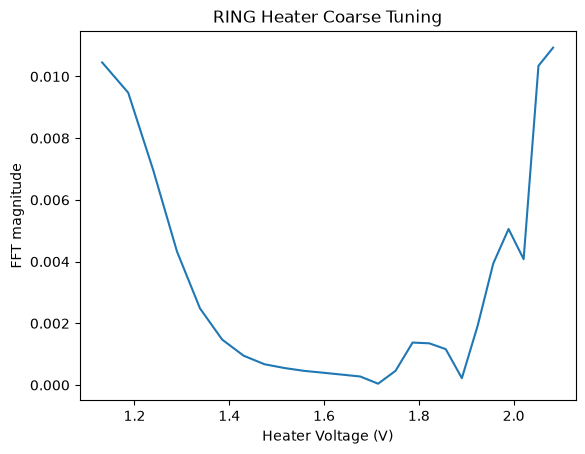

INFO:root:Best Heater voltage for RING is: 2.08 V with fft magnitude: 0.011 V


In [8]:
# Coarse tuning parameters
ring_resistance = 35 # Ohms
coarse_v_start = math.sqrt(ring_tuning_params["coarse_tuning"]["Tune_Pstart"] * ring_resistance)
coarse_v_stop = math.sqrt(ring_tuning_params["coarse_tuning"]["Tune_Pstop"] * ring_resistance)
coarse_n_step = ring_tuning_params["coarse_tuning"]["Tune_Nsteps"]

for module in modules:
    for laser in scintil_hal_laser_t:
        if laser != scintil_hal_laser_t.SCINTIL_HAL_LASER_ALL:
            # Enable dithering on Laser X
            dithering_frequency = laser_dithering_params["d_frequency"][laser.name]
            dithering_amplitude = laser_dithering_params["d_amplitude"][laser.name]
            fft_bin = int((dithering_frequency / FFT_FS) * FFT_SIZE)
            error = servoloop_laser_enable_dithering(api, module, laser, dithering_frequency, dithering_amplitude)
            assert error == scintil_hal_error_bit_t.SCINTIL_HAL_ERROR_NONE
            
            # Tune Ring using Laser X
            error = servoloop_tune_ring_coarse(api, module, coarse_v_start, coarse_v_stop, coarse_n_step, fft_bin)
            assert error == scintil_hal_error_bit_t.SCINTIL_HAL_ERROR_NONE
            
            # Disable dithering on Laser X
            ret = api.scintil_hal_laser_set_dither_state(module, laser, False)

            assert ret["errcode"] == scintil_hal_error_bit_t.SCINTIL_HAL_ERROR_NONE
            